# TP 4.a — AI Research Assistant : LangChain ReAct → LangGraph Adaptive RAG

**Formation :** Agents IA · RAG · Orchestration LangChain & n8n
**Module :** 4 — Agents IA (Jour 3)
**Durée estimée :** 2 h 15
**Pré-requis :** TP 1, TP 2 et **TP 3 terminés** — clé API Groq fonctionnelle.

---

## Objectifs

À l'issue de ce TP, vous serez capable de :

1. **Construire un agent ReAct** avec **LangChain** : transformer le retriever du TP 3 en outil, ajouter Tavily (web search) et arXiv, observer la boucle Thought → Action → Observation.
2. **Identifier les limites** d'un agent ReAct pur : boucles, hallucinations, pas d'auto-évaluation.
3. **Construire un workflow Adaptive RAG** avec **LangGraph** : `StateGraph` + 6 nodes + edges conditionnels (`grade_docs`, `grade_answer`, `rewrite`, `web_search`).
4. **Comparer** ReAct vs Adaptive RAG sur les mêmes 5 questions du golden set : qualité, latence, coût.
5. **Reconnaître** les 6 *Agentic Design Patterns* (Anthropic 2024) à l'œuvre dans votre code.

---

## Use case fil rouge — AI Research Assistant

Un agent qui répond à des questions de recherche IA en consultant **3 outils** :

1. **Retriever Chroma** — corpus IA local du TP 3 (Transformer, RAG, fine-tuning, vector DBs).
2. **Tavily Search** — recherche web LLM-friendly (free tier 1k req/mois).
3. **arXiv** — papiers scientifiques récents.

## Plan

| Partie | Sujet | Durée |
|---|---|---|
| 0 | Setup (Groq, dépendances, retriever) | 15 min |
| 1 | LangChain ReAct (5 questions golden set) | 50 min |
| 2 | Limites observées de ReAct | 15 min |
| 3 | LangGraph Adaptive RAG (workflow contrôlé) | 60 min |
| 4 | Comparaison ReAct vs Adaptive RAG | 20 min |
| 5 | Synthèse \& transition vers TP 4.b (n8n) | 5 min |


---

# PARTIE 0 — Mise en place (15 min)

## 0.1 Installation des dépendances

Décommentez la cellule suivante si vous exécutez sur un environnement vierge (Colab, nouveau venv).


In [1]:
!pip install -q langchain langchain-community langchain-groq
!pip install -q langgraph
!pip install -q tavily-python arxiv
!pip install -q chromadb sentence-transformers tiktoken
!pip install -q langchain-huggingface


## 0.2 Configuration des clés API

Deux clés sont nécessaires :

| Service | Tier gratuit | Lien | Variable |
|---|---|---|---|
| **Groq** | Très généreux (rate-limited) | https://console.groq.com | `GROQ_API_KEY` |
| **Tavily** | 1 000 requêtes / mois | https://tavily.com | `TAVILY_API_KEY` |

**Aucune carte bancaire** requise pour ces deux services.

Définissez les variables d'environnement avant de lancer Jupyter :
```bash
export GROQ_API_KEY="gsk_..."
export TAVILY_API_KEY="tvly-..."
```


In [ ]:
import os
import time
import json
from typing import TypedDict, List

from dotenv import load_dotenv
load_dotenv()  # charge les clés depuis le fichier .env à la racine du projet

# ─── Clés API ──────────────────────────────────────────────────────────────
GROQ_API_KEY   = os.environ.get("GROQ_API_KEY",   "VOTRE_CLE_GROQ_ICI")
TAVILY_API_KEY = os.environ.get("TAVILY_API_KEY", "VOTRE_CLE_TAVILY_ICI")

GROQ_MODEL = "llama-3.3-70b-versatile"

GROQ_OK   = GROQ_API_KEY.startswith("gsk_")    and len(GROQ_API_KEY)   > 30
TAVILY_OK = TAVILY_API_KEY.startswith("tvly-") and len(TAVILY_API_KEY) > 20

print(f"Groq   : {'✅ ok' if GROQ_OK   else '❌ clé manquante'}")
print(f"Tavily : {'✅ ok' if TAVILY_OK else '❌ clé manquante (web search désactivée)'}")
print(f"Modèle : {GROQ_MODEL}")


## 0.3 Reconstruire le retriever du TP 3

Pour rester **autonome**, on reconstruit ici le retriever sur le même corpus que le TP 3
(4 documents Markdown sur Transformer, RAG, fine-tuning, vector databases).

> Si vous avez déjà le TP 3 dans le même environnement Python, vous pouvez aussi importer
> directement `rag_engine.RAGEngine`. Ici on fait simple : un retriever Chroma direct.


In [3]:
from langchain_community.document_loaders import TextLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma

# ─── 1. Mini corpus IA (équivalent au TP 3) ───────────────────────────────
# Pour rester compact, on inline 4 textes (au lieu de lire 4 fichiers .md).
CORPUS = {
    "transformers.md": '''# Transformer Architecture

## Self-Attention
The Transformer architecture (Vaswani et al., 2017) replaced RNNs with self-attention.
It computes Query (Q), Key (K), Value (V) matrices and uses softmax(QK^T / sqrt(d_k)) * V.
Multi-head attention runs multiple attention heads in parallel.

## Variants
Encoder-only models (BERT), decoder-only models (GPT), encoder-decoder (T5, BART).
Modern positional encodings: RoPE (Rotary), ALiBi.''',

    "rag_systems.md": '''# Retrieval-Augmented Generation (RAG)

## Definition
RAG combines an information retrieval layer with an LLM. Responses are generated from
retrieved evidence rather than parametric memory only.

## Hybrid Retrieval
Hybrid retrieval combines sparse (BM25) and dense (embeddings) methods, fused with
Reciprocal Rank Fusion (RRF).

## Chunking
Common strategies: fixed-size, recursive, semantic, structure-aware (Markdown headers).
Optimal chunk_size depends on the use case: 256 tokens for precision, 1024 for context.''',

    "vector_databases.md": '''# Vector Databases and Indexing

## HNSW (Hierarchical Navigable Small World)
HNSW builds a multi-layer graph where each layer is a small-world network.
Search starts at the top sparse layer and refines through lower dense layers.
Achieves 95%+ recall with millisecond latency. Key params: M, ef_construction, ef_search.

## IVF (Inverted File Index)
IVF clusters vectors with k-means; search only in nearest clusters (nprobe).
Combined with PQ (product quantization) for memory savings on huge corpora.''',

    "finetuning.md": '''# LLM Fine-Tuning

## LoRA (Low-Rank Adaptation)
LoRA freezes the pre-trained model and injects trainable rank decomposition matrices
into each Transformer layer. Update is W + BA where B,A are small.

## QLoRA
QLoRA combines LoRA with 4-bit quantization. Enables fine-tuning 65B models on a single 48GB GPU.

## RLHF and DPO
RLHF: reward model + PPO. DPO: simpler, no separate reward model, classification loss on preference pairs.''',
}

from langchain_core.documents import Document
docs = [Document(page_content=text, metadata={"source": name})
        for name, text in CORPUS.items()]

# ─── 2. Splitting ─────────────────────────────────────────────────────────
splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base", chunk_size=300, chunk_overlap=30,
)
chunks = splitter.split_documents(docs)
print(f"{len(docs)} documents → {len(chunks)} chunks")

# ─── 3. Embeddings + Chroma ───────────────────────────────────────────────
embeddings = HuggingFaceEmbeddings(model_name="all-MiniLM-L6-v2")
vectorstore = Chroma.from_documents(chunks, embeddings, collection_name="tp4a_corpus")
retriever = vectorstore.as_retriever(search_kwargs={"k": 4})

print(f"Retriever prêt — collection 'tp4a_corpus' avec {vectorstore._collection.count()} chunks.")


4 documents → 4 chunks
Retriever prêt — collection 'tp4a_corpus' avec 4 chunks.


---

# PARTIE 1 — LangChain ReAct (50 min)

> **Pattern utilisé** : *Tool Use* (le LLM décide d'appeler des outils selon le contexte).

## 1.1 Pourquoi ReAct ?

Le LLM **alterne** :
- **Thought** : raisonnement en langage naturel,
- **Action** : appel d'un outil avec arguments,
- **Observation** : résultat de l'outil renvoyé au LLM.

Tant que le LLM ne produit pas `Final Answer`, on retourne à `Thought` avec l'observation injectée.
Garde-fou : `max_iterations`.


In [4]:
from langchain_core.tools import Tool

# ─── Outil 1 : retriever local du TP 3 ────────────────────────────────────
# On wrappe le retriever Chroma en outil LangChain "à la main" pour rester
# indépendant de l'emplacement (qui bouge entre versions) de
# `create_retriever_tool`.
def _rag_search(query: str) -> str:
    docs = retriever.invoke(query)
    if not docs:
        return "[Aucun document pertinent trouvé dans le corpus local]"
    return "\n\n---\n\n".join(
        f"[source: {d.metadata.get('source', '?')}]\n{d.page_content}"
        for d in docs
    )

rag_tool = Tool(
    name="rag_search",
    description=(
        "Cherche des informations dans le corpus IA local (Transformer, RAG, "
        "fine-tuning, vector databases). À utiliser pour les questions techniques "
        "sur ces sujets quand l'information est susceptible d'être dans la base."
    ),
    func=_rag_search,
)

# Test rapide
print(rag_tool.invoke("How does HNSW work?")[:400])


[source: vector_databases.md]
# Vector Databases and Indexing

## HNSW (Hierarchical Navigable Small World)
HNSW builds a multi-layer graph where each layer is a small-world network.
Search starts at the top sparse layer and refines through lower dense layers.
Achieves 95%+ recall with millisecond latency. Key params: M, ef_construction, ef_search.

## IVF (Inverted File Index)
IVF clusters vector


In [5]:
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_community.tools.arxiv.tool import ArxivQueryRun

# ─── Outil 2 : recherche web (Tavily) ─────────────────────────────────────
if TAVILY_OK:
    os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY  # pour le client interne
    tavily_tool = TavilySearchResults(
        max_results=3,
        name="tavily_web_search",
        description=(
            "Recherche sur le web public. À utiliser pour les questions récentes, "
            "hors du corpus local, ou nécessitant des informations à jour."
        ),
    )
else:
    # Stub si pas de clé Tavily (pour que le notebook tourne quand même)
    tavily_tool = Tool.from_function(
        func=lambda q: "[Tavily désactivé — pas de clé API]",
        name="tavily_web_search",
        description="Recherche web (désactivée).",
    )

# ─── Outil 3 : arXiv (papiers scientifiques) ──────────────────────────────
arxiv_tool = ArxivQueryRun()
arxiv_tool.name = "arxiv_search"
arxiv_tool.description = (
    "Cherche des papiers scientifiques sur arXiv. À utiliser pour les questions "
    "concernant des publications académiques précises (auteur, titre, papier précis)."
)

tools = [rag_tool, tavily_tool, arxiv_tool]
for t in tools:
    print(f"  • {t.name:<25} — {t.description[:80]}...")


  • rag_search                — Cherche des informations dans le corpus IA local (Transformer, RAG, fine-tuning,...
  • tavily_web_search         — Recherche sur le web public. À utiliser pour les questions récentes, hors du cor...
  • arxiv_search              — Cherche des papiers scientifiques sur arXiv. À utiliser pour les questions conce...


/var/folders/q2/01kjvnw958g_b78gjjzklwy40000gp/T/ipykernel_16548/497832116.py:7: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily_tool = TavilySearchResults(


## 1.2 System prompt de l'agent

Le **system prompt** est l'artefact le plus important : il définit **rôle**, **outils disponibles**,
**format de raisonnement**, et **garde-fous**. À versionner comme du code.


In [6]:
# System prompt de l'agent — versionné comme du code.
# Avec le `create_react_agent` de LangGraph (utilisé dans la cellule suivante),
# on passe une simple chaîne. La boucle Thought → Action → Observation est
# gérée nativement par les `tool_calls` du LLM (plus besoin de format texte
# fragile à parser comme dans l'ancien ReAct LangChain).

SYSTEM_PROMPT = """Tu es un AI Research Assistant spécialisé en intelligence artificielle.

Tu disposes de 3 outils :
- `rag_search`        : corpus IA local (Transformer, RAG, HNSW, LoRA, vector DBs).
- `tavily_web_search` : recherche web généraliste (infos récentes 2024-2026).
- `arxiv_search`      : papiers scientifiques arXiv (publications académiques précises).

RÈGLES :
- Utilise `rag_search` en priorité pour les concepts fondamentaux IA déjà bien établis
  (Transformer, RAG, HNSW, LoRA, embeddings...).
- Utilise `tavily_web_search` pour les informations récentes (2024-2026) ou hors corpus local.
- Utilise `arxiv_search` quand la question concerne un papier précis ou des publications
  académiques.
- Refuse poliment les questions hors-domaine (cuisine, météo, etc.) en français,
  SANS appeler aucun outil.
- Cite tes sources dans ta réponse finale.
- Réponds en français.
"""

print(SYSTEM_PROMPT[:300], "...")


Tu es un AI Research Assistant spécialisé en intelligence artificielle.

Tu disposes de 3 outils :
- `rag_search`        : corpus IA local (Transformer, RAG, HNSW, LoRA, vector DBs).
- `tavily_web_search` : recherche web généraliste (infos récentes 2024-2026).
- `arxiv_search`      : papiers scienti ...


In [7]:
from langgraph.prebuilt import create_react_agent
from langchain_groq import ChatGroq

# LLM
llm = ChatGroq(model=GROQ_MODEL, api_key=GROQ_API_KEY, temperature=0)

# Agent ReAct (prebuilt LangGraph — remplace l'ancien `langchain.agents.create_react_agent`
# qui a été déplacé/supprimé selon les versions). API stable, recommandée par LangChain
# en 2025-2026. Renvoie un graph compilé (pas un AgentExecutor).
agent_executor = create_react_agent(llm, tools, prompt=SYSTEM_PROMPT)

print(f"Agent ReAct (LangGraph prebuilt) prêt avec {len(tools)} outils.")


Agent ReAct (LangGraph prebuilt) prêt avec 3 outils.


/var/folders/q2/01kjvnw958g_b78gjjzklwy40000gp/T/ipykernel_16548/1420565377.py:10: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  agent_executor = create_react_agent(llm, tools, prompt=SYSTEM_PROMPT)


## 1.3 Golden set — 5 questions de référence

Ces 5 questions servent à **évaluer** l'agent et à **comparer** les implémentations.

| Q | Question | Outil(s) attendu(s) | But |
|---|---|---|---|
| Q1 | *Comment fonctionne l'algorithme HNSW pour la recherche ANN ?* | `rag_search` | Question dans le corpus local |
| Q2 | *Quels modèles d'embedding sont sortis en 2025 ?* | `tavily_web_search` | Question récente, hors corpus |
| Q3 | *Que dit le papier original LoRA (2021) sur l'efficacité paramétrique ?* | `arxiv_search` | Papier précis |
| Q4 | *Compare HNSW à des alternatives 2024-2025 utilisées en production.* | `rag_search` + `tavily` | Multi-hop |
| Q5 | *Quelle est la recette préférée de l'auteur du papier Attention is all you need ?* | refus poli | OOD adversariale |


In [8]:
golden_set = [
    {"id": "Q1",
     "question": "Comment fonctionne l'algorithme HNSW pour la recherche approximative de plus proches voisins ?",
     "expected_tools": ["rag_search"]},
    {"id": "Q2",
     "question": "Quels nouveaux modèles d'embedding open-source sont sortis en 2025 ?",
     "expected_tools": ["tavily_web_search"]},
    {"id": "Q3",
     "question": "Que dit le papier original LoRA (2021) sur l'efficacité paramétrique du fine-tuning ?",
     "expected_tools": ["arxiv_search"]},
    {"id": "Q4",
     "question": "Compare HNSW à des alternatives utilisées en production en 2024-2025.",
     "expected_tools": ["rag_search", "tavily_web_search"]},
    {"id": "Q5",
     "question": "Quelle est la recette préférée de l'auteur du papier 'Attention is all you need' ?",
     "expected_tools": []},  # On attend un refus poli
]
print(f"{len(golden_set)} questions du golden set prêtes.")


5 questions du golden set prêtes.


In [9]:
def run_react_agent(question: str) -> dict:
    """Lance l'agent ReAct (LangGraph prebuilt) et capture la trace + métriques.

    Format de sortie LangGraph : `result["messages"]` = liste ordonnée
    [HumanMessage, AIMessage(tool_calls=...), ToolMessage, ..., AIMessage final].
    On parcourt les messages pour reconstituer la trace ReAct.
    """
    if not GROQ_OK:
        return {"answer": "[Pas de clé Groq]", "tools_used": [], "steps": 0, "duration_s": 0}
    t0 = time.time()
    try:
        result = agent_executor.invoke(
            {"messages": [("user", question)]},
            {"recursion_limit": 12},      # garde-fou anti-boucle
        )
        duration = time.time() - t0

        messages = result["messages"]

        # Extraire la liste des outils appelés (depuis les AIMessages avec tool_calls)
        tools_used = []
        for msg in messages:
            for tc in getattr(msg, "tool_calls", []) or []:
                tools_used.append(tc["name"])

        # Réponse finale = dernier AIMessage avec du contenu non vide
        final_answer = ""
        for msg in reversed(messages):
            if msg.__class__.__name__ == "AIMessage" and getattr(msg, "content", ""):
                final_answer = msg.content
                break

        # Affichage verbose façon ReAct (Thought / Action / Observation)
        for msg in messages:
            cls = msg.__class__.__name__
            if cls == "AIMessage":
                if msg.tool_calls:
                    for tc in msg.tool_calls:
                        print(f"  🤖 Action  : {tc['name']}({tc['args']})")
                elif msg.content:
                    print(f"  💬 Final   : {msg.content[:200]}{'…' if len(msg.content) > 200 else ''}")
            elif cls == "ToolMessage":
                preview = str(msg.content)[:160].replace("\n", " ")
                print(f"  📥 Observation [{msg.name}] : {preview}…")

        return {
            "answer": final_answer,
            "tools_used": tools_used,
            "steps": len(tools_used),
            "duration_s": round(duration, 2),
        }
    except Exception as e:
        return {"answer": f"[Erreur : {e}]", "tools_used": [], "steps": 0,
                "duration_s": round(time.time() - t0, 2)}


# Exécution sur les 5 questions du golden set
react_results = {}
for item in golden_set:
    print("\n" + "=" * 80)
    print(f"### {item['id']} : {item['question']}")
    print("=" * 80)
    react_results[item["id"]] = run_react_agent(item["question"])
    r = react_results[item["id"]]
    print(f"\n📊 Outils utilisés : {r['tools_used']}")
    print(f"⏱  Durée : {r['duration_s']}s | Étapes : {r['steps']}")



### Q1 : Comment fonctionne l'algorithme HNSW pour la recherche approximative de plus proches voisins ?

📊 Outils utilisés : []
⏱  Durée : 0.47s | Étapes : 0

### Q2 : Quels nouveaux modèles d'embedding open-source sont sortis en 2025 ?
  🤖 Action  : tavily_web_search({'query': "nouveaux modèles d'embedding open-source 2025"})
  📥 Observation [tavily_web_search] : [{"title": "The Best Embedding Models for Information Retrieval in 2025 - DEV Community", "url": "https://dev.to/datastax/the-best-embedding-models-for-informat…
  💬 Final   : Les nouveaux modèles d'embedding open-source sortis en 2025 incluent :

* Voyage-3-large
* Voyage-3-lite
* Stella
* BGE-M3
* E5-Mistral
* Voyage-Multilingual 2

Ces modèles offrent des performances él…

📊 Outils utilisés : ['tavily_web_search']
⏱  Durée : 3.9s | Étapes : 1

### Q3 : Que dit le papier original LoRA (2021) sur l'efficacité paramétrique du fine-tuning ?
  🤖 Action  : arxiv_search({'query': 'LoRA 2021 parametric efficiency fine-tuning'})
 

---

# PARTIE 2 — Limites observées de ReAct (15 min)

Avant de passer à LangGraph, prenez 5 minutes pour observer les traces ci-dessus
et noter les limites de ReAct.

## Limites typiques

| Limite | Symptôme | Conséquence |
|---|---|---|
| **Pas d'auto-évaluation** | L'agent répond même si les chunks récupérés sont hors-sujet | Hallucinations possibles |
| **Pas de fallback web automatique** | Si `rag_search` échoue, l'agent peut conclure à tort | Réponses incomplètes |
| **Boucles** | L'agent peut osciller entre 2 outils sans converger | Coût × N |
| **Format fragile** | Une mauvaise sortie casse le parsing | Erreur en milieu de chaîne |
| **Pas de "grade"** | Pas de check explicite *est-ce que la réponse est bien ancrée ?* | Faithfulness non garantie |

## Ce que LangGraph va apporter

> Un **workflow contrôlé** où le développeur fixe les nœuds (`retrieve`, `grade_docs`, `generate`,
> `grade_answer`) et le LLM ne décide qu'aux **branches conditionnelles**.

C'est le pattern **Agentic Workflow** (vs *Agent autonome* avec ReAct).


---

# PARTIE 3 — LangGraph Adaptive RAG (60 min)

> **Patterns utilisés** : *Routing* (grade docs / grade answer décident des branches), *Reflection loop* (auto-évaluation), *Tool use* (web fallback).

## 3.1 Architecture du workflow

```
                 ┌─────────────┐
   question ───▶│  retrieve   │──────▶ ┌──────────────┐
                 └─────────────┘        │  grade_docs  │
                                        └──────┬───────┘
                          docs OK ?            │
                       ┌──────yes──────────────┤
                       ▼                       │ no
                 ┌─────────────┐               ▼
                 │  generate   │         ┌──────────┐
                 └──────┬──────┘         │ rewrite  │
                        ▼                └────┬─────┘
                ┌──────────────┐              │
                │ grade_answer │              ▼ (back to retrieve)
                └──────┬───────┘
        answer OK ?    │
   ┌──────yes──────────┤
   ▼                   │ no
  END             ┌──────────────┐
                  │  web_search  │──▶ generate
                  └──────────────┘
```

Le workflow a **6 nodes** + **2 edges conditionnels** (les deux "grade" diamants).


In [10]:
from typing import TypedDict, List, Annotated
from operator import add

class AgentState(TypedDict):
    """État partagé entre tous les nodes du graph."""
    question: str          # question courante (peut être réécrite)
    original_question: str # question originale (pour traces)
    docs: List[str]        # chunks récupérés
    answer: str            # réponse générée
    docs_ok: bool          # résultat du grade_docs
    answer_ok: bool        # résultat du grade_answer
    iterations: int        # compteur (anti-boucle)
    tools_used: List[str]  # log des outils appelés


In [11]:
import re

# ─── Helper LLM ───────────────────────────────────────────────────────────
def llm_json(prompt: str, max_tokens: int = 200) -> dict:
    """Appelle le LLM en attendant un JSON strict."""
    resp = llm.invoke(prompt + "\n\nRéponds UNIQUEMENT par un JSON valide.")
    text = resp.content
    m = re.search(r"\{.*\}", text, re.DOTALL)
    if not m:
        return {}
    try:
        return json.loads(m.group())
    except Exception:
        return {}


# ─── Node 1 : retrieve ────────────────────────────────────────────────────
def n_retrieve(state: AgentState) -> dict:
    docs = retriever.invoke(state["question"])
    return {
        "docs": [d.page_content for d in docs],
        "tools_used": state.get("tools_used", []) + ["rag_search"],
    }


# ─── Node 2 : grade_docs (Reflection pattern) ─────────────────────────────
def n_grade_docs(state: AgentState) -> dict:
    if not state["docs"]:
        return {"docs_ok": False}
    chunks_str = "\n---\n".join(state["docs"][:3])
    out = llm_json(
        f"Question : {state['question']}\n\n"
        f"Documents récupérés :\n{chunks_str}\n\n"
        f"Les documents ci-dessus contiennent-ils une réponse pertinente à la question ? "
        f'Réponds en JSON : {{"score": "yes" ou "no", "reason": "..."}}'
    )
    return {"docs_ok": out.get("score", "no") == "yes"}


# ─── Node 3 : rewrite (Chaining pattern) ──────────────────────────────────
def n_rewrite(state: AgentState) -> dict:
    new_q = llm.invoke(
        f"La question suivante n'a pas trouvé de réponse pertinente dans le corpus. "
        f"Réécris-la pour la rendre plus efficace en recherche documentaire "
        f"(termes techniques explicites, anglais si pertinent).\n\n"
        f"Question originale : {state['question']}\n\n"
        f"Renvoie UNIQUEMENT la requête réécrite."
    ).content.strip().strip('"')
    return {
        "question": new_q,
        "iterations": state.get("iterations", 0) + 1,
    }


# ─── Node 4 : generate ────────────────────────────────────────────────────
def n_generate(state: AgentState) -> dict:
    context = "\n---\n".join(state["docs"])
    answer = llm.invoke(
        f"Tu es un AI Research Assistant. Réponds à la question en français, en t'appuyant "
        f"UNIQUEMENT sur le contexte fourni. Cite les sources.\n\n"
        f"Contexte :\n{context}\n\n"
        f"Question : {state['original_question']}\n\n"
        f"Réponse :"
    ).content
    return {"answer": answer}


# ─── Node 5 : grade_answer (Reflection pattern) ───────────────────────────
def n_grade_answer(state: AgentState) -> dict:
    out = llm_json(
        f"Question : {state['original_question']}\n\n"
        f"Contexte (sources) :\n{chr(10).join(state['docs'][:3])}\n\n"
        f"Réponse de l'assistant :\n{state['answer']}\n\n"
        f"La réponse est-elle (1) pertinente pour la question ET "
        f"(2) entièrement supportée par le contexte ? "
        f'Réponds en JSON : {{"score": "yes" ou "no"}}'
    )
    return {"answer_ok": out.get("score", "no") == "yes"}


# ─── Node 6 : web_search (Tool use pattern, fallback) ─────────────────────
def n_web_search(state: AgentState) -> dict:
    if not TAVILY_OK:
        web_chunks = ["[Tavily désactivé — clé API manquante]"]
    else:
        try:
            results = tavily_tool.invoke(state["question"])
            web_chunks = [
                f"[Web {i+1}: {r.get('url', '?')}]\n{r.get('content', '')[:500]}"
                for i, r in enumerate(results)
            ]
        except Exception as e:
            web_chunks = [f"[Erreur Tavily : {e}]"]
    return {
        "docs": state["docs"] + web_chunks,
        "tools_used": state.get("tools_used", []) + ["tavily_web_search"],
    }


print("6 nodes définis : retrieve · grade_docs · rewrite · generate · grade_answer · web_search")


6 nodes définis : retrieve · grade_docs · rewrite · generate · grade_answer · web_search


In [12]:
from langgraph.graph import StateGraph, END

# ─── Construction du graphe ───────────────────────────────────────────────
g = StateGraph(AgentState)

# Add nodes
g.add_node("retrieve",     n_retrieve)
g.add_node("grade_docs",   n_grade_docs)
g.add_node("rewrite",      n_rewrite)
g.add_node("generate",     n_generate)
g.add_node("grade_answer", n_grade_answer)
g.add_node("web_search",   n_web_search)

# Entry point
g.set_entry_point("retrieve")

# Edges fixes
g.add_edge("retrieve", "grade_docs")
g.add_edge("rewrite",  "retrieve")
g.add_edge("generate", "grade_answer")
g.add_edge("web_search", "generate")

# Edge conditionnel : après grade_docs
def route_after_grade_docs(state: AgentState) -> str:
    if state.get("docs_ok"):
        return "generate"
    if state.get("iterations", 0) >= 2:
        # On a déjà réécrit 2 fois sans succès → on bascule sur le web
        return "web_search"
    return "rewrite"

g.add_conditional_edges("grade_docs", route_after_grade_docs,
                        {"generate": "generate", "rewrite": "rewrite", "web_search": "web_search"})

# Edge conditionnel : après grade_answer
def route_after_grade_answer(state: AgentState) -> str:
    if state.get("answer_ok"):
        return END
    return "web_search"

g.add_conditional_edges("grade_answer", route_after_grade_answer,
                        {END: END, "web_search": "web_search"})

# Compile
adaptive_rag = g.compile()
print("✅ Workflow Adaptive RAG compilé.")


✅ Workflow Adaptive RAG compilé.


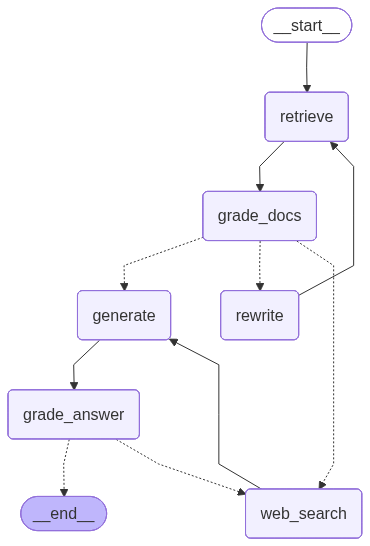

In [13]:
# ─── Visualisation du graph ──────────────────────────────────────────────
try:
    from IPython.display import Image, display
    png_bytes = adaptive_rag.get_graph().draw_mermaid_png()
    display(Image(png_bytes))
except Exception as e:
    print(f"[Visualisation indisponible : {e}]")
    print("\nStructure textuelle :")
    print(adaptive_rag.get_graph().draw_ascii())


In [14]:
def run_adaptive_rag(question: str) -> dict:
    """Lance le workflow Adaptive RAG et capture la trace + métriques."""
    if not GROQ_OK:
        return {"answer": "[Pas de clé Groq]", "tools_used": [], "duration_s": 0,
                "iterations": 0, "docs_ok": False, "answer_ok": False}
    t0 = time.time()
    initial_state = {
        "question": question,
        "original_question": question,
        "docs": [], "answer": "", "docs_ok": False, "answer_ok": False,
        "iterations": 0, "tools_used": [],
    }
    try:
        # Limite de récursion globale (anti-boucle)
        final_state = adaptive_rag.invoke(initial_state, {"recursion_limit": 12})
        return {
            "answer": final_state["answer"],
            "tools_used": final_state.get("tools_used", []),
            "duration_s": round(time.time() - t0, 2),
            "iterations": final_state.get("iterations", 0),
            "docs_ok": final_state.get("docs_ok", False),
            "answer_ok": final_state.get("answer_ok", False),
        }
    except Exception as e:
        return {"answer": f"[Erreur : {e}]", "tools_used": [],
                "duration_s": round(time.time() - t0, 2), "iterations": 0,
                "docs_ok": False, "answer_ok": False}


# Exécution sur les 5 questions
graph_results = {}
for item in golden_set:
    print("\n" + "=" * 80)
    print(f"### {item['id']} : {item['question']}")
    print("=" * 80)
    r = run_adaptive_rag(item["question"])
    graph_results[item["id"]] = r
    print(f"\n📊 Outils : {r['tools_used']}")
    print(f"⏱  Durée : {r['duration_s']}s | Réécritures : {r['iterations']}")
    print(f"   docs_ok : {r['docs_ok']} | answer_ok : {r['answer_ok']}")
    print(f"\n💬 Réponse :\n{r['answer'][:400]}")



### Q1 : Comment fonctionne l'algorithme HNSW pour la recherche approximative de plus proches voisins ?

📊 Outils : ['rag_search', 'tavily_web_search', 'tavily_web_search']
⏱  Durée : 18.5s | Réécritures : 0
   docs_ok : True | answer_ok : True

💬 Réponse :
L'algorithme HNSW (Hierarchical Navigable Small World) est conçu pour optimiser la recherche vectorielle pour les données à haute dimension en créant une structure basée sur un graphique. Cette structure permet de trouver plus rapidement des voisins approximatifs dans de grandes collections de vecteurs.

Selon les sources [Web 1](https://fr.community.intersystems.com/post/recherches-vectorielles-p

### Q2 : Quels nouveaux modèles d'embedding open-source sont sortis en 2025 ?

📊 Outils : []
⏱  Durée : 26.1s | Réécritures : 0
   docs_ok : False | answer_ok : False

💬 Réponse :
[Erreur : Recursion limit of 12 reached without hitting a stop condition. You can increase the limit by setting the `recursion_limit` config key.
For troublesh

---

# PARTIE 4 — Comparaison ReAct vs Adaptive RAG (20 min)

On compare les deux implémentations sur **les 5 mêmes questions** du golden set selon :

- **Outils utilisés** : sont-ils ceux qu'on attendait ?
- **Latence** : durée totale de la chaîne.
- **Robustesse** : Q5 (OOD) et Q4 (multi-hop) sont les vraies épreuves.


In [15]:
import pandas as pd

rows = []
for item in golden_set:
    qid = item["id"]
    react = react_results[qid]
    graph = graph_results[qid]
    rows.append({
        "Q":           qid,
        "Outils ReAct":     " + ".join(react["tools_used"]) or "—",
        "Outils LangGraph": " + ".join(graph["tools_used"]) or "—",
        "Latence ReAct (s)":     react["duration_s"],
        "Latence LangGraph (s)": graph["duration_s"],
        "Étapes ReAct":   react["steps"],
        "Réécritures Graph": graph["iterations"],
        "answer_ok (Graph)": "✅" if graph["answer_ok"] else "❌",
    })

df = pd.DataFrame(rows)
df


,Q,Outils ReAct,Outils LangGraph,Latence ReAct (s),Latence LangGraph (s),Étapes ReAct,Réécritures Graph,answer_ok (Graph)
0,Q1,—,rag_search + tavily_web_search + tavily_web_se...,0.47,18.50,0,0,✅
1,Q2,tavily_web_search,—,3.90,26.10,1,0,❌
2,Q3,arxiv_search,—,3.27,42.60,1,0,❌
3,Q4,tavily_web_search,—,3.29,0.13,1,0,❌
4,Q5,—,—,0.81,0.08,0,0,❌


## 4.2 Lecture des résultats

Quelques questions à se poser après l'exécution :

1. **Q5 (OOD adversariale)** — *Quelle est la recette préférée…* :
   - L'agent ReAct a-t-il refusé proprement ? A-t-il appelé un outil inutile ?
   - Le workflow LangGraph a-t-il fait un fallback web inutile ?
   → Pour le système le plus robuste, on ajoute typiquement un **node `gate_question`** en entrée
   qui détecte les questions hors-domaine.

2. **Q4 (multi-hop)** — *Compare HNSW à des alternatives 2024-2025* :
   - Combien d'outils chaque implémentation a-t-elle réellement utilisés ?
   - Le workflow Adaptive RAG a-t-il bien combiné `retriever` + `web_search` ?

3. **Latence** :
   - LangGraph est typiquement **plus prévisible** mais avec **plus d'appels** (les grade nodes coûtent).
   - ReAct est plus rapide quand il converge vite, mais plus volatile.

4. **Coût** :
   - Estimer (tokens ⨉ tarif Groq) — la cellule LangSmith ci-dessous trace tout en détail.


## 4.3 Observabilité avec LangSmith *(optionnel)*

Pour aller plus loin, activez **LangSmith** : chaque tour ReAct et chaque node LangGraph
sera tracé avec ses inputs/outputs, latence et tokens.


In [16]:
# Décommenter et configurer pour activer LangSmith
# os.environ["LANGSMITH_TRACING"] = "true"
# os.environ["LANGSMITH_API_KEY"] = "lsv2_..."   # https://smith.langchain.com
# os.environ["LANGSMITH_PROJECT"] = "tp4a-research-assistant"
#
# # Puis re-exécuter run_react_agent / run_adaptive_rag — les traces apparaissent automatiquement.
print("LangSmith non activé. Pour activer : voir cellule ci-dessus.")


LangSmith non activé. Pour activer : voir cellule ci-dessus.


---

# PARTIE 5 — Synthèse \& transition vers TP 4.b (5 min)

## Les 6 *Agentic Design Patterns* dans votre code

| Pattern | Où dans ce TP ? |
|---|---|
| **1. Prompt chaining** | Node `rewrite` (sortie du LLM → entrée du retrieve) |
| **2. Parallélisation** | *(non utilisé ici — pertinent pour multi-source en parallèle)* |
| **3. Routing** | `add_conditional_edges` après `grade_docs` (3 branches possibles) |
| **4. Reflection loop** | Nodes `grade_docs` et `grade_answer` (auto-évaluation) |
| **5. Orchestrator-workers** | *(scénario 3 du TP 4.b en bonus)* |
| **6. Tool use (ReAct)** | Toute la Partie 1 — le LLM décide d'appeler un outil |

## Ce que vous avez livré

- ✅ Un agent **ReAct LangChain** avec 3 outils (RAG + Tavily + arXiv).
- ✅ Un workflow **Adaptive RAG LangGraph** avec 6 nodes et 2 edges conditionnels.
- ✅ Un golden set de 5 questions exécuté sur les **deux** implémentations.
- ✅ Un tableau comparatif chiffré (latence, outils, succès).

## Transition vers le TP 4.b

> Le **même use case AI Research Assistant**, transposé en **no-code avec n8n** :
> - 3 scénarios progressifs (ReAct simple → Adaptive RAG → Orchestrator bonus).
> - Workflow visuel avec AI Agent node.
> - `workflow.json` importable en quelques clics.

→ Ouvrez le markdown **`TP4-b/tp4b-n8n-research-assistant.md`** pour la suite.
